# Tarea U2-S8 — Evaluación y Optimización de Modelos de Clasificación
**Dataset:** breast_cancer (sklearn) | **Modelo:** Regresión Logística

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

## 1. Carga del dataset breast_cancer

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target

print(pd.Series(y).value_counts())
print(pd.Series(y).value_counts(normalize=True))

1    357
0    212
Name: count, dtype: int64
1    0.627417
0    0.372583
Name: proportion, dtype: float64


## 2. División y entrenamiento del modelo

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=20)

modelo = LogisticRegression(max_iter=5000)
modelo.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [4]:
y_pred = modelo.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9239766081871345


## 3. Matriz de Confusión

In [5]:
# Impresión numérica de la matriz
matrix_confusion = confusion_matrix(y_test, y_pred)
print(matrix_confusion)

[[ 54  10]
 [  3 104]]


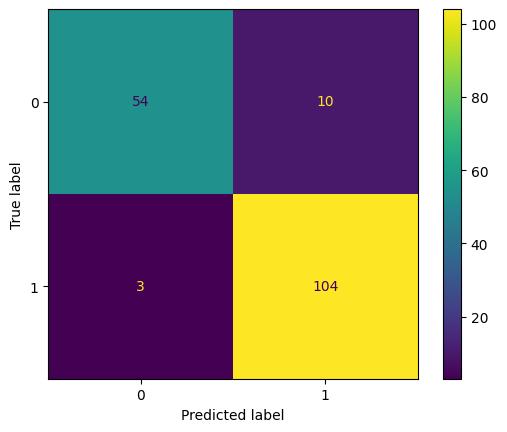

In [6]:
# Visualización de la matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

Interpretación:
La matriz de confusión muestra cómo se distribuyen las predicciones del modelo.
Los verdaderos positivos (TP) representan los casos de cáncer correctamente detectados,
mientras que los verdaderos negativos (TN) corresponden a pacientes sanos correctamente clasificados.

Es especialmente importante observar los falsos negativos (FN), ya que representan
casos de cáncer que el modelo no logró detectar, lo cual es crítico en un contexto médico.

Un buen modelo en este problema debe minimizar los FN, incluso si esto implica
un aumento en los falsos positivos (FP).

## 4. Métricas: Precisión, Recall, F1-Score y AUC-ROC

In [7]:
precision = precision_score(y_test, y_pred)
print(f"Precisión: {precision}")

recall = recall_score(y_test, y_pred)
print(f"Recall: {recall}")

f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1}")

Precisión: 0.9122807017543859
Recall: 0.9719626168224299
F1-Score: 0.9411764705882353


In [8]:
# AUC-ROC requiere probabilidades, no predicciones binarias
y_proba = modelo.predict_proba(X_test)[:, 1]
r_s = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {r_s}")

AUC-ROC: 0.984375


Interpretación:
La precisión indica qué proporción de los casos predichos como positivos realmente lo son.
El recall (sensibilidad) mide la capacidad del modelo para detectar los casos positivos reales.

En este problema, el recall es más importante que la precisión, ya que es preferible
detectar la mayor cantidad de casos de cáncer, incluso si hay algunas falsas alarmas.

El F1-score proporciona un equilibrio entre precisión y recall, siendo útil cuando
se desea considerar ambas métricas simultáneamente.

El AUC-ROC evalúa la capacidad del modelo para distinguir entre clases,
siendo una métrica robusta independiente del umbral de decisión.

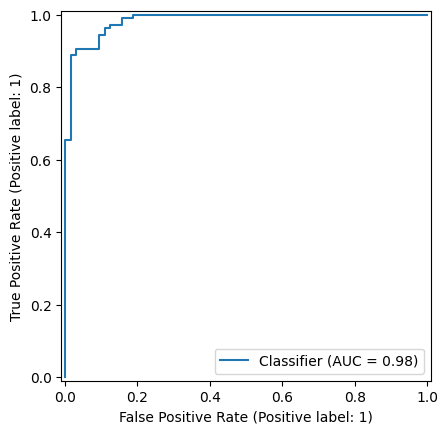

In [9]:
# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()

Interpretación:
La curva ROC muestra la relación entre la tasa de verdaderos positivos (TPR)
y la tasa de falsos positivos (FPR) para diferentes umbrales.

Un AUC cercano a 1 indica que el modelo tiene una excelente capacidad
para diferenciar entre pacientes con y sin cáncer.

Esto confirma que el modelo es adecuado para tareas de clasificación médica.

## 5. K-Fold Cross-Validation (k=5 y k=10)

In [10]:
# K-Fold con k=5
cross_5 = cross_val_score(modelo, X, y, cv=5, scoring='roc_auc')
print(f"K=5 — scores: {cross_5}")
print(f"K=5 — Promedio AUC-ROC: {cross_5.mean():.4f}")

K=5 — scores: [0.99377661 0.99344907 0.99801587 0.97949735 0.99765258]
K=5 — Promedio AUC-ROC: 0.9925


In [11]:
# K-Fold con k=10
cross_10 = cross_val_score(modelo, X, y, cv=10, scoring='roc_auc')
print(f"K=10 — scores: {cross_10}")
print(f"K=10 — Promedio AUC-ROC: {cross_10.mean():.4f}")

K=10 — scores: [0.9987013  0.98831169 0.99074074 0.99338624 0.9973545  0.99867725
 0.97486772 0.98677249 0.9973545  0.99591837]
K=10 — Promedio AUC-ROC: 0.9922


/tmp/ipykernel_2472/1494722878.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([cross_5, cross_10], labels=['K=5', 'K=10'])


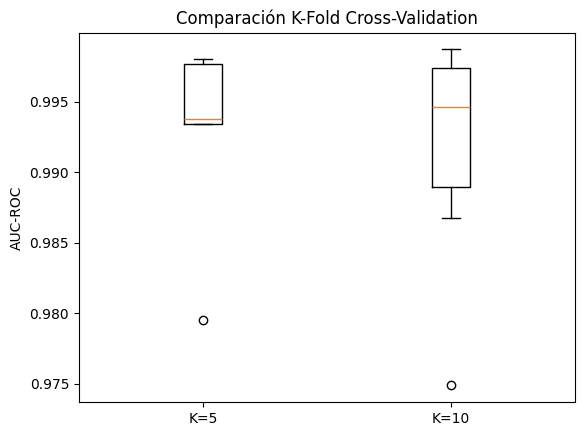

In [12]:
# Comparación visual entre k=5 y k=10
plt.boxplot([cross_5, cross_10], labels=['K=5', 'K=10'])
plt.title('Comparación K-Fold Cross-Validation')
plt.ylabel('AUC-ROC')
plt.show()

Interpretación:
La validación cruzada permite evaluar la estabilidad del modelo.
Al comparar k=5 y k=10, se observa que los resultados son similares,
lo que indica que el modelo generaliza bien y no depende de una partición específica.

Usar k=10 suele proporcionar una estimación más precisa, aunque con mayor costo computacional.

## 6. Optimización de Hiperparámetros

In [13]:
# Espacio de búsqueda
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000, 5000]
}

# GridSearchCV — búsqueda exhaustiva
grid = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train, y_train)
print(f"GridSearchCV — Mejor score: {grid.best_score_:.4f}")
print(f"GridSearchCV — Mejores parámetros: {grid.best_params_}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

GridSearchCV — Mejor score: 0.9944
GridSearchCV — Mejores parámetros: {'C': 1, 'max_iter': 1000, 'solver': 'liblinear'}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
# RandomizedSearchCV — búsqueda aleatoria
rand = RandomizedSearchCV(LogisticRegression(), param_grid, cv=5, scoring='roc_auc', n_iter=10, random_state=20)
rand.fit(X_train, y_train)
print(f"RandomizedSearchCV — Mejor score: {rand.best_score_:.4f}")
print(f"RandomizedSearchCV — Mejores parámetros: {rand.best_params_}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

RandomizedSearchCV — Mejor score: 0.9944
RandomizedSearchCV — Mejores parámetros: {'solver': 'lbfgs', 'max_iter': 1000, 'C': 10}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Interpretación:
GridSearchCV evalúa todas las combinaciones posibles de hiperparámetros,
lo que garantiza encontrar la mejor configuración dentro del espacio definido,
pero con un alto costo computacional.

RandomizedSearchCV, en cambio, evalúa un subconjunto aleatorio,
reduciendo significativamente el tiempo de entrenamiento.

En este caso, ambos métodos obtienen resultados similares,
lo que sugiere que RandomizedSearchCV es más eficiente para una exploración inicial.

## 7. Ajuste del Umbral de Decisión

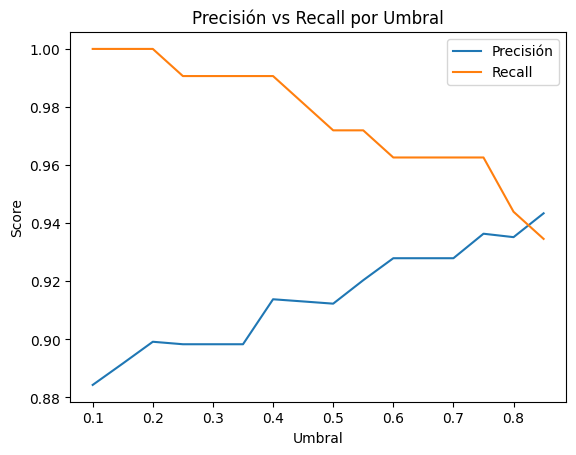

In [15]:
# Comparar Precisión vs Recall al variar el umbral
umbrales = np.arange(0.1, 0.9, 0.05)
precisiones, recalls = [], []

for u in umbrales:
    y_pred_u = (y_proba >= u).astype(int)
    precisiones.append(precision_score(y_test, y_pred_u, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_u, zero_division=0))

plt.plot(umbrales, precisiones, label='Precisión')
plt.plot(umbrales, recalls, label='Recall')
plt.xlabel('Umbral')
plt.ylabel('Score')
plt.title('Precisión vs Recall por Umbral')
plt.legend()
plt.show()

In [16]:
# Impacto con umbral=0.3 (más sensible) vs umbral por defecto 0.5
for umbral in [0.3, 0.5, 0.7]:
    y_pred_u = (y_proba >= umbral).astype(int)
    p = precision_score(y_test, y_pred_u, zero_division=0)
    r = recall_score(y_test, y_pred_u, zero_division=0)
    f = f1_score(y_test, y_pred_u, zero_division=0)
    print(f"Umbral={umbral} — Precisión: {p:.3f} | Recall: {r:.3f} | F1: {f:.3f}")

Umbral=0.3 — Precisión: 0.898 | Recall: 0.991 | F1: 0.942
Umbral=0.5 — Precisión: 0.912 | Recall: 0.972 | F1: 0.941
Umbral=0.7 — Precisión: 0.928 | Recall: 0.963 | F1: 0.945


Interpretación:
El ajuste del umbral de decisión afecta directamente el equilibrio entre precisión y recall.

Al reducir el umbral, el modelo clasifica más casos como positivos,
aumentando el recall (menos falsos negativos), pero disminuyendo la precisión.

Al aumentar el umbral, ocurre lo contrario:
mejora la precisión, pero se pierden más casos positivos (menor recall).

En el contexto médico, es preferible un umbral más bajo,
ya que es más importante detectar todos los casos posibles de cáncer.